# Experiment 9: mT5-small + LoRA — Full Dataset

## What Changes From Previous Experiments

All previous experiments used 1600 or 4,000 training samples (500 per language)
as a proxy to identify the best configuration cheaply. This experiment
scales up the best configuration to the full dataset.

Key decisions carried forward from small-data experiments:
- Short instruction prompt with language name (best in Exp 6)
- LoRA r=4, lora_alpha=8 (r=16 needs more data, confirmed in Exp 7)
- decoder_start_token_id=pad_token_id (fixed in Exp 4)
- no_repeat_ngram_size=3 (prevents repetition loops)

New decisions for full-data run:
- MAX_INPUT_LENGTH=192 — gives full instruction prompt room without
  truncating questions (prompt adds ~25 tokens, 99.5% of questions
  fit within 128 tokens, so 192 gives comfortable headroom)
- MAX_TARGET_LENGTH=320 — covers 90th percentile of answer lengths,
  reduces truncated training labels from 28% to 10%
- Evaluation on 300 stratified val samples during training to keep
  eval fast while still tracking learning curve
- Full val (1,200 samples) evaluated once after training for reporting

## Hypothesis

Scaling the best small-data configuration to the full dataset should
produce significantly higher ROUGE scores and more coherent multilingual
answers, particularly for low-resource languages that had limited
representation in the small dataset.

In [1]:
!pip install -q torchao==0.16.0
!pip install -q transformers datasets evaluate accelerate peft sentencepiece rouge-score

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import DataLoader

transformers.logging.set_verbosity_error()

In [3]:
train = pd.read_csv("/kaggle/input/datasets/sharifkiviiri/multi-lingual-dataset/train_clean.csv")
val   = pd.read_csv("/kaggle/input/datasets/sharifkiviiri/multi-lingual-dataset/val_small2.csv")
test  = pd.read_csv("/kaggle/input/datasets/sharifkiviiri/multi-lingual-dataset/test_clean.csv")

print("Full train:", train.shape)
print("Full val  :", val.shape)
print("Full test :", test.shape)
print()
print("Train language distribution:")
print(train["subset"].value_counts())

Full train: (29751, 10)
Full val  : (1200, 4)
Full test : (2618, 3)

Train language distribution:
subset
Eng_Uga    7591
Aka_Gha    4455
Eng_Gha    4443
Eng_Eth    3886
Lug_Uga    3383
Eng_Ken    2078
Swa_Ken    2070
Amh_Eth    1845
Name: count, dtype: int64


In [4]:
LANGUAGE_MAP = {
    "Aka_Gha": "Akan",
    "Amh_Eth": "Amharic",
    "Lug_Uga": "Luganda",
    "Swa_Ken": "Swahili",
    "Eng_Eth": "English",
    "Eng_Gha": "English",
    "Eng_Ken": "English",
    "Eng_Uga": "English"
}

def apply_prompt(df):
    df = df.copy()
    df["input"] = df.apply(
        lambda row: (
            f"You are a health expert. "
            f"Answer the following question in {LANGUAGE_MAP[row['subset']]}.\n"
            f"Question: {row['input']}\n"
            f"Answer:"
        ),
        axis=1
    )
    return df

train = apply_prompt(train)
val   = apply_prompt(val)
test  = apply_prompt(test)

print("Sample prompt:")
print(train["input"].iloc[0])

Sample prompt:
You are a health expert. Answer the following question in Akan.
Question: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.
Answer:


In [5]:
def make_small(df, n_per_lang, seed=42):
    parts = []
    for lang in df["subset"].unique():
        chunk = df[df["subset"] == lang]
        parts.append(
            chunk.sample(min(n_per_lang, len(chunk)), random_state=seed)
        )
    return pd.concat(parts).reset_index(drop=True)

val_small_eval = make_small(val, 38)   # ~300 total, one per language

print("val_small_eval:", val_small_eval.shape)
print(val_small_eval["subset"].value_counts())

val_small_eval: (304, 4)
subset
Aka_Gha    38
Amh_Eth    38
Eng_Eth    38
Eng_Gha    38
Eng_Ken    38
Eng_Uga    38
Lug_Uga    38
Swa_Ken    38
Name: count, dtype: int64


In [6]:
train_ds      = Dataset.from_pandas(train)
val_eval_ds   = Dataset.from_pandas(val_small_eval)
val_full_ds   = Dataset.from_pandas(val)
test_ds       = Dataset.from_pandas(test)

print("train_ds     :", len(train_ds))
print("val_eval_ds  :", len(val_eval_ds))
print("val_full_ds  :", len(val_full_ds))
print("test_ds      :", len(test_ds))

train_ds     : 29751
val_eval_ds  : 304
val_full_ds  : 1200
test_ds      : 2618


In [7]:
MODEL_NAME        = "google/mt5-small"
MAX_INPUT_LENGTH  = 192
MAX_TARGET_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("pad_token_id     :", tokenizer.pad_token_id)
print("MAX_INPUT_LENGTH :", MAX_INPUT_LENGTH)
print("MAX_TARGET_LENGTH:", MAX_TARGET_LENGTH)

pad_token_id     : 0
MAX_INPUT_LENGTH : 192
MAX_TARGET_LENGTH: 256


In [8]:
def tokenize(examples):
    inputs = tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )
    targets = tokenizer(
        text_target=examples["output"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )
    inputs["labels"] = [
        [t if t != tokenizer.pad_token_id else -100 for t in ids]
        for ids in targets["input_ids"]
    ]
    return inputs

def tokenize_test(examples):
    return tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

tok_train    = train_ds.map(tokenize,     batched=True, remove_columns=train_ds.column_names)
tok_val_eval = val_eval_ds.map(tokenize,  batched=True, remove_columns=val_eval_ds.column_names)
tok_val_full = val_full_ds.map(tokenize,  batched=True, remove_columns=val_full_ds.column_names)
tok_test     = test_ds.map(tokenize_test, batched=True, remove_columns=test_ds.column_names)

print(tok_train)

# Verify input lengths
lengths = [len(x) for x in tok_train["input_ids"]]
print(f"\nInput lengths — mean: {np.mean(lengths):.0f} | "
      f"95th pct: {np.percentile(lengths, 95):.0f} | "
      f"max: {max(lengths)}")

# Verify label lengths
label_lengths = [sum(t != -100 for t in x) for x in tok_train["labels"]]
print(f"Label lengths — mean: {np.mean(label_lengths):.0f} | "
      f"95th pct: {np.percentile(label_lengths, 95):.0f} | "
      f"max: {max(label_lengths)}")

Map:   0%|          | 0/29751 [00:00<?, ? examples/s]

Map:   0%|          | 0/304 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2618 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 29751
})

Input lengths — mean: 50 | 95th pct: 93 | max: 192
Label lengths — mean: 133 | 95th pct: 256 | max: 256


In [9]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.float()

model.config.decoder_start_token_id = tokenizer.pad_token_id
model.config.forced_bos_token_id    = None

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=4,
    lora_alpha=8,
    lora_dropout=0.1,
    target_modules=["q", "v"],
    bias="none"
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

trainable params: 172,032 || all params: 556,463,488 || trainable%: 0.0309


In [10]:
collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

In [11]:
rouge = evaluate.load("rouge")

def clean(text):
    return re.sub(r"<extra_id_\d+>", "", text).strip()

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds  = np.clip(preds, 0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds  = [clean(t) for t in
                      tokenizer.batch_decode(preds,  skip_special_tokens=True)]
    decoded_labels = tokenizer.batch_decode(labels,  skip_special_tokens=True)
    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {
        "ROUGE1": round(scores["rouge1"], 4),
        "ROUGEL": round(scores["rougeL"], 4)
    }

In [12]:
args = Seq2SeqTrainingArguments(
    output_dir="/kaggle/working/checkpoints/exp9",

    num_train_epochs=3,
    learning_rate=3e-4,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    weight_decay=0.01,
    max_grad_norm=1.0,

    fp16=False,
    bf16=False,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="ROUGE1",
    greater_is_better=True,

    generation_max_length=256,
    generation_num_beams=1,

    predict_with_generate=True,

    logging_strategy="steps",
    logging_steps=50,
    save_total_limit=1,
    dataloader_num_workers=2,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tok_train,
    eval_dataset=tok_val_eval,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

In [13]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '181.6', 'grad_norm': '1647', 'learning_rate': '0.0002947', 'epoch': '0.05378'}
{'loss': '114', 'grad_norm': '209.9', 'learning_rate': '0.0002894', 'epoch': '0.1076'}
{'loss': '71.62', 'grad_norm': '31.6', 'learning_rate': '0.000284', 'epoch': '0.1613'}
{'loss': '55.45', 'grad_norm': '6.373', 'learning_rate': '0.0002786', 'epoch': '0.2151'}
{'loss': '49', 'grad_norm': '9.521', 'learning_rate': '0.0002732', 'epoch': '0.2689'}
{'loss': '45.98', 'grad_norm': '5.933', 'learning_rate': '0.0002678', 'epoch': '0.3227'}
{'loss': '44.39', 'grad_norm': '4.035', 'learning_rate': '0.0002625', 'epoch': '0.3764'}
{'loss': '43.67', 'grad_norm': '4.577', 'learning_rate': '0.0002571', 'epoch': '0.4302'}
{'loss': '42.87', 'grad_norm': '4.113', 'learning_rate': '0.0002517', 'epoch': '0.484'}
{'loss': '42.21', 'grad_norm': '6.338', 'learning_rate': '0.0002463', 'epoch': '0.5378'}
{'loss': '41.83', 'grad_norm': '5.617', 'learning_rate': '0.000241', 'epoch': '0.5916'}
{'loss': '41.29', 'grad_norm':

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '40.07', 'grad_norm': '6.622', 'learning_rate': '0.000198', 'epoch': '1.022'}
{'loss': '40.13', 'grad_norm': '5.538', 'learning_rate': '0.0001926', 'epoch': '1.075'}
{'loss': '40.28', 'grad_norm': '4.833', 'learning_rate': '0.0001872', 'epoch': '1.129'}
{'loss': '40.25', 'grad_norm': '5.051', 'learning_rate': '0.0001818', 'epoch': '1.183'}
{'loss': '39.41', 'grad_norm': '4.296', 'learning_rate': '0.0001765', 'epoch': '1.237'}
{'loss': '39.22', 'grad_norm': '4.417', 'learning_rate': '0.0001711', 'epoch': '1.29'}
{'loss': '39.27', 'grad_norm': '4.926', 'learning_rate': '0.0001657', 'epoch': '1.344'}
{'loss': '39.47', 'grad_norm': '4.911', 'learning_rate': '0.0001603', 'epoch': '1.398'}
{'loss': '39.56', 'grad_norm': '4.949', 'learning_rate': '0.0001549', 'epoch': '1.452'}
{'loss': '39.3', 'grad_norm': '6.338', 'learning_rate': '0.0001496', 'epoch': '1.506'}
{'loss': '39.31', 'grad_norm': '4.833', 'learning_rate': '0.0001442', 'epoch': '1.559'}
{'loss': '38.94', 'grad_norm': '20.

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '38.55', 'grad_norm': '6.089', 'learning_rate': '9.581e-05', 'epoch': '2.043'}
{'loss': '38.71', 'grad_norm': '4.509', 'learning_rate': '9.043e-05', 'epoch': '2.097'}
{'loss': '38.65', 'grad_norm': '5.273', 'learning_rate': '8.505e-05', 'epoch': '2.151'}
{'loss': '38.65', 'grad_norm': '5.373', 'learning_rate': '7.968e-05', 'epoch': '2.204'}
{'loss': '38.53', 'grad_norm': '5.894', 'learning_rate': '7.43e-05', 'epoch': '2.258'}
{'loss': '38.5', 'grad_norm': '4.859', 'learning_rate': '6.892e-05', 'epoch': '2.312'}
{'loss': '38.67', 'grad_norm': '4.385', 'learning_rate': '6.355e-05', 'epoch': '2.366'}
{'loss': '38.21', 'grad_norm': '4.43', 'learning_rate': '5.817e-05', 'epoch': '2.419'}
{'loss': '38.34', 'grad_norm': '4.755', 'learning_rate': '5.28e-05', 'epoch': '2.473'}
{'loss': '38.22', 'grad_norm': '5.194', 'learning_rate': '4.742e-05', 'epoch': '2.527'}
{'loss': '38.34', 'grad_norm': '5.541', 'learning_rate': '4.204e-05', 'epoch': '2.581'}
{'loss': '38.37', 'grad_norm': '5.32

TrainOutput(global_step=2790, training_loss=44.58080284638217, metrics={'train_runtime': 9961.517, 'train_samples_per_second': 8.96, 'train_steps_per_second': 0.28, 'train_loss': 44.58080284638217, 'epoch': 3.0})

In [14]:
trainer.save_model("/kaggle/working/models/exp9/best_model")
tokenizer.save_pretrained("/kaggle/working/models/exp9/best_model")
print("Model saved to /kaggle/working/")

Model saved to /kaggle/working/


In [21]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def generate_predictions(tok_dataset, has_labels=True, batch_size=8):
    loader = DataLoader(
        tok_dataset,
        batch_size=batch_size,
        collate_fn=DataCollatorForSeq2Seq(
            tokenizer=tokenizer,
            model=model,
            padding=True,
            pad_to_multiple_of=8
        )
    )

    preds = []
    refs  = []

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=256,
                num_beams=1,
                decoder_start_token_id=tokenizer.pad_token_id,
                forced_bos_token_id=None,
                no_repeat_ngram_size=3
            )

        preds.extend([
            clean(t) for t in
            tokenizer.batch_decode(outputs, skip_special_tokens=True)
        ])

        if has_labels:
            labels = batch["labels"]
            labels = torch.where(
                labels != -100, labels, tokenizer.pad_token_id
            )
            refs.extend(
                tokenizer.batch_decode(labels, skip_special_tokens=True)
            )

    return preds, refs

In [16]:
print("Running full val predictions...")
val_preds, val_refs = generate_predictions(tok_val_full, batch_size=16)

scores = rouge.compute(
    predictions=val_preds,
    references=val_refs,
    use_stemmer=True
)
print("Full Val ROUGE-1:", round(scores["rouge1"], 4))
print("Full Val ROUGE-L:", round(scores["rougeL"], 4))

Running full val predictions...
Full Val ROUGE-1: 0.1457
Full Val ROUGE-L: 0.1138


In [17]:
# Inspect examples — one per language
for lang in ["Aka_Gha", "Amh_Eth", "Lug_Uga", "Swa_Ken", "Eng_Uga"]:
    idx = val[val["subset"] == lang].index[0]
    print("="*70)
    print("LANGUAGE :", lang)
    print("QUESTION :", val.iloc[idx]["input"][:150])
    print("REFERENCE:", val_refs[idx][:250])
    print("GENERATED:", val_preds[idx][:250])
    print()

LANGUAGE : Aka_Gha
QUESTION : You are a health expert. Answer the following question in Akan.
Question: So amammerɛ anaa nyamesom mu nsusuwii ahorow bi wɔ hɔ a, ebetumi aka sɛnea a
REFERENCE: Yiw, amammerɛ ne nyamesom mu gyidi ahorow betumi anya sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho no so nkɛntɛnso kɛse. Amammerɛ anaa ɔsom ahorow bi betumi asi ahobrɛase, twe a wɔtwe wɔn ho fi ho ansa na wɔaware, an
GENERATED: nsusuwii ahorow bi wɔ hɔ a, nsɛm ho nsuwii ahorows bi wɔ ho a nsumɛm nnsusuwi ahorow yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho sɛma nsamɛm.

LANGUAGE : Amh_Eth
QUESTION : You are a health expert. Answer the following question in Amharic.
Question: አንዲት ሴት በእርግዝና ወቅት በቂጥኝ በሽታ መያዟ ከተረጋገጠ፣ በምን ያህል በፍጥነት ሕክምና ማግኘት አለባት?
Ans
REFERENCE: ወዲያውኑ። የጨብጥ ተሕዋሱ ወደ ፅንሱ እንዳይዛመት ለመከላከል ምርመራው እንደተከናወነ የፔኒሲሊን ሕክምና በተቻለ ፍጥነት መሰጠት አለበት።
GENERATED: በቂጥኝ በሽታ መያዟ ላይ ጥቅም ላይ መያዛት ላይ ይገኛል.

LANGUAGE : Lug_Uga
QUESTION : You are a health expert. Answer the followin

In [22]:
print("Generating test predictions...")
test_preds, _ = generate_predictions(tok_test, has_labels=False, batch_size=8)
print(f"Done — {len(test_preds)} predictions")
print("Sample:", test_preds[0][:200])

Generating test predictions...
Done — 2618 predictions
Sample: a wɔreyɛ adwumayɛbea ahorow, ne akuo ahorow a bɛyɛ adwuayɛba ahorow.


In [23]:
submission = pd.DataFrame({
    "ID":         test["ID"],
    "TargetRLF1": test_preds,
    "TargetR1F1": test_preds,
    "TargetLLM":  test_preds
})

submission.to_csv("/kaggle/working/submission_exp9.csv", index=False)

print("Submission saved — rows:", len(submission))
print(submission.head(3))

Submission saved — rows: 2618
                       ID                                         TargetRLF1  \
0  ID_TS_Aka_Gha_A3B1799D  a wɔreyɛ adwumayɛbea ahorow, ne akuo ahorow a ...   
1  ID_TS_Aka_Gha_1C80317F  a a wobu so no mu a wɔbu so a hobu so mu n'a w...   
2  ID_TS_Aka_Gha_06671AD1  a wɔbɛgyina ho a ɛfa nnipa a wobɛgyine ho nsus...   

                                          TargetR1F1  \
0  a wɔreyɛ adwumayɛbea ahorow, ne akuo ahorow a ...   
1  a a wobu so no mu a wɔbu so a hobu so mu n'a w...   
2  a wɔbɛgyina ho a ɛfa nnipa a wobɛgyine ho nsus...   

                                           TargetLLM  
0  a wɔreyɛ adwumayɛbea ahorow, ne akuo ahorow a ...  
1  a a wobu so no mu a wɔbu so a hobu so mu n'a w...  
2  a wɔbɛgyina ho a ɛfa nnipa a wobɛgyine ho nsus...  


# Experiment 10: flan-t5-base + LoRA — Full Dataset

## Why We Switched From mT5 to flan-t5-base

Experiments 2-9 used mT5-small. Despite training on
29,751 samples across multiple configurations, mT5 consistently
produced incoherent outputs. Root cause analysis revealed:

mT5 was pretrained with span corruption — it learned to fill
<extra_id_0> sentinel tokens, not generate answers. Token ID 250099
(<extra_id_0>) was always the first generated token regardless of
fine-tuning because LoRA (0.3-1.2% trainable parameters) was not
enough to overcome this deeply ingrained pretraining behaviour.

flan-t5-base was tested with zero fine-tuning and immediately
generated coherent, medically relevant answers:
- "What are symptoms of malaria?" → fever, chills, headache, nausea
- "How is HIV transmitted?" → via syringe, sexual contact

This confirmed flan-t5-base already understands the QA task from
its instruction fine-tuning on 1,800+ tasks. We are now building
on top of that foundation rather than fighting against pretraining.

## Configuration

- Model: google/flan-t5-base (250M parameters, instruction-tuned)
- LoRA: r=8, lora_alpha=16 — more capacity than r=4
- Prompt: "Answer this health question in {language}: {question}"
  — format confirmed working on base model before fine-tuning
- MAX_INPUT_LENGTH: 160 — eliminates the 4.9% truncation seen
  with 128 when using instruction-style prompts
- MAX_TARGET_LENGTH: 256 — covers 75th percentile of answers
- Learning rate: 1e-4 with warmup_steps=200 — stable on full data
- No decoder_start_token_id fix needed — flan-t5 generates correctly

In [35]:
!pip install -q torchao==0.16.0
!pip install -q transformers datasets evaluate accelerate peft sentencepiece rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 35.1 MB/s eta 0:00:0000:0100:01


In [36]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import DataLoader

transformers.logging.set_verbosity_error()

print("GPUs available:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}:", torch.cuda.get_device_name(i),
          f"| {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")

GPUs available: 2
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB


In [37]:
train = pd.read_csv("/kaggle/input/datasets/sharifkiviiri/multi-lingual-dataset/train_clean.csv")
val   = pd.read_csv("/kaggle/input/datasets/sharifkiviiri/multi-lingual-dataset/val_small2.csv")
test  = pd.read_csv("/kaggle/input/datasets/sharifkiviiri/multi-lingual-dataset/test_clean.csv")

print("Full train:", train.shape)
print("Full val  :", val.shape)
print("Full test :", test.shape)
print()
print("Train language distribution:")
print(train["subset"].value_counts())

Full train: (29751, 10)
Full val  : (1200, 4)
Full test : (2618, 3)

Train language distribution:
subset
Eng_Uga    7591
Aka_Gha    4455
Eng_Gha    4443
Eng_Eth    3886
Lug_Uga    3383
Eng_Ken    2078
Swa_Ken    2070
Amh_Eth    1845
Name: count, dtype: int64


In [38]:
LANGUAGE_MAP = {
    "Aka_Gha": "Akan",
    "Amh_Eth": "Amharic",
    "Lug_Uga": "Luganda",
    "Swa_Ken": "Swahili",
    "Eng_Eth": "English",
    "Eng_Gha": "English",
    "Eng_Ken": "English",
    "Eng_Uga": "English"
}

def apply_prompt(df):
    df = df.copy()
    df["input"] = df.apply(
        lambda row: (
            f"Answer this health question in "
            f"{LANGUAGE_MAP[row['subset']]}: {row['input']}"
        ),
        axis=1
    )
    return df

train = apply_prompt(train)
val   = apply_prompt(val)
test  = apply_prompt(test)

print("Sample prompt:")
print(train["input"].iloc[0])
print()
print("Sample answer:")
print(train["output"].iloc[0][:200])

Sample prompt:
Answer this health question in Akan: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.

Sample answer:
Mmabun betumi aboa atipɛnfo a ebia nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ so denam: Nkate fam mmoa a wɔde bɛma na wɔagye wɔn nkate atom a wɔremmu atɛn anaasɛ wɔmfa asodi nto wɔn so. Wɔn a wɔbɛhyɛ wɔn


In [39]:
def make_small(df, n_per_lang, seed=42):
    parts = []
    for lang in df["subset"].unique():
        chunk = df[df["subset"] == lang]
        parts.append(
            chunk.sample(min(n_per_lang, len(chunk)), random_state=seed)
        )
    return pd.concat(parts).reset_index(drop=True)

val_small_eval = make_small(val, 38)

print("val_small_eval:", val_small_eval.shape)
print(val_small_eval["subset"].value_counts())

val_small_eval: (304, 4)
subset
Aka_Gha    38
Amh_Eth    38
Eng_Eth    38
Eng_Gha    38
Eng_Ken    38
Eng_Uga    38
Lug_Uga    38
Swa_Ken    38
Name: count, dtype: int64


In [40]:
train_ds      = Dataset.from_pandas(train)
val_eval_ds   = Dataset.from_pandas(val_small_eval)
val_full_ds   = Dataset.from_pandas(val)
test_ds       = Dataset.from_pandas(test)

print("train_ds     :", len(train_ds))
print("val_eval_ds  :", len(val_eval_ds))
print("val_full_ds  :", len(val_full_ds))
print("test_ds      :", len(test_ds))

train_ds     : 29751
val_eval_ds  : 304
val_full_ds  : 1200
test_ds      : 2618


In [41]:
MODEL_NAME        = "google/flan-t5-base"
MAX_INPUT_LENGTH  = 160
MAX_TARGET_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("pad_token_id:", tokenizer.pad_token_id)
print("eos_token_id:", tokenizer.eos_token_id)

pad_token_id: 0
eos_token_id: 1


In [42]:
def tokenize(examples):
    inputs = tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )
    targets = tokenizer(
        text_target=examples["output"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )
    inputs["labels"] = [
        [t if t != tokenizer.pad_token_id else -100 for t in ids]
        for ids in targets["input_ids"]
    ]
    return inputs

def tokenize_test(examples):
    return tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

tok_train    = train_ds.map(tokenize,     batched=True, remove_columns=train_ds.column_names)
tok_val_eval = val_eval_ds.map(tokenize,  batched=True, remove_columns=val_eval_ds.column_names)
tok_val_full = val_full_ds.map(tokenize,  batched=True, remove_columns=val_full_ds.column_names)
tok_test     = test_ds.map(tokenize_test, batched=True, remove_columns=test_ds.column_names)

print(tok_train)

input_lengths = [len(x) for x in tok_train["input_ids"]]
label_lengths = [sum(t != -100 for t in x) for x in tok_train["labels"]]

print(f"\nInput  — mean: {np.mean(input_lengths):.0f} | "
      f"95th pct: {np.percentile(input_lengths, 95):.0f} | "
      f"max: {max(input_lengths)}")
print(f"Labels — mean: {np.mean(label_lengths):.0f} | "
      f"95th pct: {np.percentile(label_lengths, 95):.0f} | "
      f"max: {max(label_lengths)}")
print(f"Truncated inputs : {sum(l == MAX_INPUT_LENGTH for l in input_lengths)} "
      f"({sum(l == MAX_INPUT_LENGTH for l in input_lengths)/len(input_lengths)*100:.1f}%)")
print(f"Truncated labels : {sum(l == MAX_TARGET_LENGTH for l in label_lengths)} "
      f"({sum(l == MAX_TARGET_LENGTH for l in label_lengths)/len(label_lengths)*100:.1f}%)")

Map:   0%|          | 0/29751 [00:00<?, ? examples/s]

Map:   0%|          | 0/304 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2618 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 29751
})

Input  — mean: 45 | 95th pct: 128 | max: 160
Labels — mean: 138 | 95th pct: 256 | max: 256
Truncated inputs : 676 (2.3%)
Truncated labels : 7664 (25.8%)


In [43]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.float()

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q", "v"],
    bias="none"
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

# Verify initial loss is normal
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

sample_batch = DataCollatorForSeq2Seq(
    tokenizer=tokenizer, model=model,
    padding=True, label_pad_token_id=-100
)(list(tok_train.select(range(4))))

with torch.no_grad():
    out = model(
        input_ids=sample_batch["input_ids"].to(device),
        attention_mask=sample_batch["attention_mask"].to(device),
        labels=sample_batch["labels"].to(device)
    )
print("Initial loss (expect 3-6):", round(out.loss.item(), 4))

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

trainable params: 884,736 || all params: 248,462,592 || trainable%: 0.3561
Initial loss (expect 3-6): 9.8326


In [44]:
collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

In [45]:
rouge = evaluate.load("rouge")

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds  = np.clip(preds, 0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds  = tokenizer.batch_decode(preds,  skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {
        "ROUGE1": round(scores["rouge1"], 4),
        "ROUGEL": round(scores["rougeL"], 4)
    }

In [46]:
args = Seq2SeqTrainingArguments(
    output_dir="/kaggle/working/checkpoints/exp10",

    num_train_epochs=3,
    learning_rate=1e-4,
    warmup_steps=200,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    weight_decay=0.01,
    max_grad_norm=1.0,

    fp16=False,
    bf16=False,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="ROUGE1",
    greater_is_better=True,

    generation_max_length=256,
    generation_num_beams=1,

    predict_with_generate=True,

    logging_strategy="steps",
    logging_steps=100,
    save_total_limit=2,
    dataloader_num_workers=0,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tok_train,
    eval_dataset=tok_val_eval,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

In [47]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '78.61', 'grad_norm': '1.121', 'learning_rate': '4.95e-05', 'epoch': '0.1076'}
{'loss': '75.08', 'grad_norm': '2.155', 'learning_rate': '9.95e-05', 'epoch': '0.2151'}
{'loss': '68.76', 'grad_norm': '3.167', 'learning_rate': '9.618e-05', 'epoch': '0.3227'}
{'loss': '64.77', 'grad_norm': '3.514', 'learning_rate': '9.232e-05', 'epoch': '0.4302'}
{'loss': '62.84', 'grad_norm': '2.159', 'learning_rate': '8.846e-05', 'epoch': '0.5378'}
{'loss': '61.68', 'grad_norm': '1.518', 'learning_rate': '8.459e-05', 'epoch': '0.6453'}
{'loss': '60.8', 'grad_norm': '2.142', 'learning_rate': '8.073e-05', 'epoch': '0.7529'}
{'loss': '60.14', 'grad_norm': '2.399', 'learning_rate': '7.687e-05', 'epoch': '0.8604'}
{'loss': '59.82', 'grad_norm': '3.442', 'learning_rate': '7.301e-05', 'epoch': '0.968'}
{'eval_loss': '6.813', 'eval_ROUGE1': '0.0122', 'eval_ROUGEL': '0.0122', 'eval_runtime': '249.9', 'eval_samples_per_second': '1.216', 'eval_steps_per_second': '0.152', 'epoch': '1'}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '59.48', 'grad_norm': '1.939', 'learning_rate': '6.915e-05', 'epoch': '1.075'}
{'loss': '59.18', 'grad_norm': '1.725', 'learning_rate': '6.529e-05', 'epoch': '1.183'}
{'loss': '58.92', 'grad_norm': '1.323', 'learning_rate': '6.143e-05', 'epoch': '1.29'}
{'loss': '58.67', 'grad_norm': '1.752', 'learning_rate': '5.757e-05', 'epoch': '1.398'}
{'loss': '58.65', 'grad_norm': '1.871', 'learning_rate': '5.371e-05', 'epoch': '1.506'}
{'loss': '58.24', 'grad_norm': '1.923', 'learning_rate': '4.985e-05', 'epoch': '1.613'}
{'loss': '58.12', 'grad_norm': '1.457', 'learning_rate': '4.598e-05', 'epoch': '1.721'}
{'loss': '57.91', 'grad_norm': '1.365', 'learning_rate': '4.212e-05', 'epoch': '1.828'}
{'loss': '57.84', 'grad_norm': '2.59', 'learning_rate': '3.826e-05', 'epoch': '1.936'}
{'eval_loss': '6.594', 'eval_ROUGE1': '0.0114', 'eval_ROUGEL': '0.0114', 'eval_runtime': '251.9', 'eval_samples_per_second': '1.207', 'eval_steps_per_second': '0.151', 'epoch': '2'}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '57.74', 'grad_norm': '1.913', 'learning_rate': '3.44e-05', 'epoch': '2.043'}
{'loss': '57.67', 'grad_norm': '1.571', 'learning_rate': '3.054e-05', 'epoch': '2.151'}
{'loss': '57.58', 'grad_norm': '2.061', 'learning_rate': '2.668e-05', 'epoch': '2.258'}
{'loss': '57.5', 'grad_norm': '2.185', 'learning_rate': '2.282e-05', 'epoch': '2.366'}
{'loss': '57.59', 'grad_norm': '1.506', 'learning_rate': '1.896e-05', 'epoch': '2.473'}
{'loss': '57.52', 'grad_norm': '1.892', 'learning_rate': '1.51e-05', 'epoch': '2.581'}
{'loss': '57.41', 'grad_norm': '1.814', 'learning_rate': '1.124e-05', 'epoch': '2.688'}
{'loss': '57.26', 'grad_norm': '1.46', 'learning_rate': '7.375e-06', 'epoch': '2.796'}
{'loss': '57.24', 'grad_norm': '1.521', 'learning_rate': '3.514e-06', 'epoch': '2.903'}
{'eval_loss': '6.55', 'eval_ROUGE1': '0.0083', 'eval_ROUGEL': '0.0083', 'eval_runtime': '250.8', 'eval_samples_per_second': '1.212', 'eval_steps_per_second': '0.152', 'epoch': '3'}
{'train_runtime': '6992', 'trai

TrainOutput(global_step=2790, training_loss=60.5199215249776, metrics={'train_runtime': 6992.0832, 'train_samples_per_second': 12.765, 'train_steps_per_second': 0.399, 'train_loss': 60.5199215249776, 'epoch': 3.0})

In [48]:
trainer.save_model("/kaggle/working/models/exp10/best_model")
tokenizer.save_pretrained("/kaggle/working/models/exp10/best_model")
print("Model saved")

Model saved


In [49]:
model.eval()

def generate_predictions(tok_dataset, has_labels=True, batch_size=8):
    loader = DataLoader(
        tok_dataset,
        batch_size=batch_size,
        collate_fn=DataCollatorForSeq2Seq(
            tokenizer=tokenizer,
            model=model,
            padding=True,
            pad_to_multiple_of=8
        )
    )

    preds = []
    refs  = []

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=256,
                num_beams=4,
                no_repeat_ngram_size=3,
                early_stopping=True,
                length_penalty=2.0
            )

        preds.extend(
            tokenizer.batch_decode(outputs, skip_special_tokens=True)
        )

        if has_labels:
            labels = batch["labels"]
            labels = torch.where(
                labels != -100, labels, tokenizer.pad_token_id
            )
            refs.extend(
                tokenizer.batch_decode(labels, skip_special_tokens=True)
            )

    return preds, refs

In [50]:
print("Generating test predictions...")
test_preds, _ = generate_predictions(tok_test, has_labels=False, batch_size=8)
print(f"Done — {len(test_preds)} predictions")
print()
print("Sample predictions:")
for i in range(3):
    print(f"[{test['subset'].iloc[i]}]", test_preds[i][:150])
    print()

Generating test predictions...
Done — 2618 predictions

Sample predictions:
[Aka_Gha] aia aaao aya na oaai aoai, ata iaayi oia, ooaa eaasa uaaea tiai iii noa ka ya. a aa ba wa ma da ca pa la saati toasi eoaye adaao ota,, iana, and ahoi 

[Aka_Gha] a ia na ya oa ta ea ka aaai aoao ati ni oia, ada a ua ba ma wa sa ca pa ra ha di ioaa li to ooa aya,, iii yi eoai, no ita. asaasi ko ne aiaana, and ah

[Aka_Gha] a ia na oa a, ni a. aa ea ya ta ba ua ma ka da wa ca sa pa ha ra la fa i ii no oi oti to io aaai yi ki uia,, aya, and asaa gi bi mi ei o ne ia, ina en



In [51]:
submission = pd.DataFrame({
    "ID":         test["ID"],
    "TargetRLF1": test_preds,
    "TargetR1F1": test_preds,
    "TargetLLM":  test_preds
})

submission.to_csv("/kaggle/working/submission_exp10.csv", index=False)
print("Submission saved — rows:", len(submission))
print(submission.head(3))

Submission saved — rows: 2618
                       ID                                         TargetRLF1  \
0  ID_TS_Aka_Gha_A3B1799D  aia aaao aya na oaai aoai, ata iaayi oia, ooaa...   
1  ID_TS_Aka_Gha_1C80317F  a ia na ya oa ta ea ka aaai aoao ati ni oia, a...   
2  ID_TS_Aka_Gha_06671AD1  a ia na oa a, ni a. aa ea ya ta ba ua ma ka da...   

                                          TargetR1F1  \
0  aia aaao aya na oaai aoai, ata iaayi oia, ooaa...   
1  a ia na ya oa ta ea ka aaai aoao ati ni oia, a...   
2  a ia na oa a, ni a. aa ea ya ta ba ua ma ka da...   

                                           TargetLLM  
0  aia aaao aya na oaai aoai, ata iaayi oia, ooaa...  
1  a ia na ya oa ta ea ka aaai aoao ati ni oia, a...  
2  a ia na oa a, ni a. aa ea ya ta ba ua ma ka da...  


# Experiment 11: mT5-base + LoRA — Full Dataset

## What We Learned From Experiment 9 and 10

Experiment 9 on full data with mT5-small produced lower ROUGE than
our best small-data experiment (0.1097 vs 0.1655). Investigation
revealed the cause: learning rate 3e-4 caused gradient explosion on
full data — grad_norm hit 1647 at step 1, the model never converged
properly, and loss plateaued at 38 instead of dropping to single digits.

Exp 10 disappointly performed so so bad that we have to go back to the mt5 models.

## What Changes In Experiment 11

1. Model: mT5-small → mT5-base
   mT5-base has 580M parameters vs 300M for small. Experiment 8
   showed it generates better quality text even on limited data.
   With the full dataset it should show clear improvement in ROUGE.

2. Learning rate: 3e-4 → 1e-4
   Lower learning rate prevents the gradient explosion seen in Exp 10.

3. Warmup steps: 0 → 200
   Gradually ramps learning rate from 0 to 1e-4 over the first 200
   steps. This stabilizes early training when gradients are largest.

4. LoRA rank: r=4 → r=8, lora_alpha=16
   r=4 was chosen for small data to avoid overfitting. With 29,751
   samples r=8 gives more capacity without the data insufficiency
   problem seen with r=16 in Experiment 7.

5. Short prompt restored
   "health qa {language}: {question}" — performed best in Exp 6 and
   avoids any risk of truncation. Long prompt added no measurable
   benefit over short prompt.

## Hypothesis

Stable training with lower learning rate and warmup, combined with
mT5-base's greater capacity and the full dataset, will produce
significantly higher ROUGE scores and more coherent answers across
all 8 languages.

In [1]:
!pip install -q torchao==0.16.0
!pip install -q transformers datasets evaluate accelerate peft sentencepiece rouge-score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 89.2 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requ

In [2]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
from datasets import Dataset
import evaluate
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments
)
from peft import LoraConfig, TaskType, get_peft_model
from torch.utils.data import DataLoader

transformers.logging.set_verbosity_error()

print("GPUs available:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f"  GPU {i}:", torch.cuda.get_device_name(i),
          f"| {torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB")

GPUs available: 2
  GPU 0: Tesla T4 | 15.6 GB
  GPU 1: Tesla T4 | 15.6 GB


In [3]:
train = pd.read_csv("/kaggle/input/datasets/sharifkiviiri/multi-lingual-dataset/train_clean.csv")
val   = pd.read_csv("/kaggle/input/datasets/sharifkiviiri/multi-lingual-dataset/val_small2.csv")
test  = pd.read_csv("/kaggle/input/datasets/sharifkiviiri/multi-lingual-dataset/test_clean.csv")

print("Full train:", train.shape)
print("Full val  :", val.shape)
print("Full test :", test.shape)
print()
print("Train language distribution:")
print(train["subset"].value_counts())

Full train: (29751, 10)
Full val  : (1200, 4)
Full test : (2618, 3)

Train language distribution:
subset
Eng_Uga    7591
Aka_Gha    4455
Eng_Gha    4443
Eng_Eth    3886
Lug_Uga    3383
Eng_Ken    2078
Swa_Ken    2070
Amh_Eth    1845
Name: count, dtype: int64


In [4]:
LANGUAGE_MAP = {
    "Aka_Gha": "Akan",
    "Amh_Eth": "Amharic",
    "Lug_Uga": "Luganda",
    "Swa_Ken": "Swahili",
    "Eng_Eth": "English",
    "Eng_Gha": "English",
    "Eng_Ken": "English",
    "Eng_Uga": "English"
}

def apply_prompt(df):
    df = df.copy()
    df["input"] = df.apply(
        lambda row: f"health qa {LANGUAGE_MAP[row['subset']]}: {row['input']}",
        axis=1
    )
    return df

train = apply_prompt(train)
val   = apply_prompt(val)
test  = apply_prompt(test)

print("Sample prompt:")
print(train["input"].iloc[0])

Sample prompt:
health qa Akan: Ɔkwan bɛn so na mmabunbɛtumi aboa wɔn mfɛfoɔ a nsa anaa nnubɔne ama wɔayɛ wɔn ayayadeɛ? Yei bi ne sɛnea wɔbɛkyekye wɔn werɛ, sɛnea wɔbɛboa wɔn ma wɔanya mmoa firi nnwumakuo a ɛfata hɔ, ne sɛnea wɔbɛsiw afɔbu suban ne nsɛm a nkurɔfoɔ de gu oyarefoɔ no so no kwan.


In [5]:
def make_small(df, n_per_lang, seed=42):
    parts = []
    for lang in df["subset"].unique():
        chunk = df[df["subset"] == lang]
        parts.append(
            chunk.sample(min(n_per_lang, len(chunk)), random_state=seed)
        )
    return pd.concat(parts).reset_index(drop=True)

val_small_eval = make_small(val, 38)

print("val_small_eval:", val_small_eval.shape)
print(val_small_eval["subset"].value_counts())

val_small_eval: (304, 4)
subset
Aka_Gha    38
Amh_Eth    38
Eng_Eth    38
Eng_Gha    38
Eng_Ken    38
Eng_Uga    38
Lug_Uga    38
Swa_Ken    38
Name: count, dtype: int64


In [6]:
train_ds      = Dataset.from_pandas(train)
val_eval_ds   = Dataset.from_pandas(val_small_eval)
val_full_ds   = Dataset.from_pandas(val)
test_ds       = Dataset.from_pandas(test)

print("train_ds     :", len(train_ds))
print("val_eval_ds  :", len(val_eval_ds))
print("val_full_ds  :", len(val_full_ds))
print("test_ds      :", len(test_ds))

train_ds     : 29751
val_eval_ds  : 304
val_full_ds  : 1200
test_ds      : 2618


In [7]:
MODEL_NAME        = "google/mt5-base"
MAX_INPUT_LENGTH  = 128
MAX_TARGET_LENGTH = 256

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print("pad_token_id     :", tokenizer.pad_token_id)
print("MAX_INPUT_LENGTH :", MAX_INPUT_LENGTH)
print("MAX_TARGET_LENGTH:", MAX_TARGET_LENGTH)

config.json:   0%|          | 0.00/702 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/65.0 [00:00<?, ?B/s]

pad_token_id     : 0
MAX_INPUT_LENGTH : 128
MAX_TARGET_LENGTH: 256


In [8]:
def tokenize(examples):
    inputs = tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )
    targets = tokenizer(
        text_target=examples["output"],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )
    inputs["labels"] = [
        [t if t != tokenizer.pad_token_id else -100 for t in ids]
        for ids in targets["input_ids"]
    ]
    return inputs

def tokenize_test(examples):
    return tokenizer(
        examples["input"],
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False
    )

tok_train    = train_ds.map(tokenize,     batched=True, remove_columns=train_ds.column_names)
tok_val_eval = val_eval_ds.map(tokenize,  batched=True, remove_columns=val_eval_ds.column_names)
tok_val_full = val_full_ds.map(tokenize,  batched=True, remove_columns=val_full_ds.column_names)
tok_test     = test_ds.map(tokenize_test, batched=True, remove_columns=test_ds.column_names)

print(tok_train)

input_lengths = [len(x) for x in tok_train["input_ids"]]
label_lengths = [sum(t != -100 for t in x) for x in tok_train["labels"]]

print(f"\nInput  — mean: {np.mean(input_lengths):.0f} | "
      f"95th pct: {np.percentile(input_lengths, 95):.0f} | "
      f"max: {max(input_lengths)}")
print(f"Labels — mean: {np.mean(label_lengths):.0f} | "
      f"95th pct: {np.percentile(label_lengths, 95):.0f} | "
      f"max: {max(label_lengths)}")
print(f"Truncated inputs : {sum(l == MAX_INPUT_LENGTH for l in input_lengths)}")
print(f"Truncated labels : {sum(l == MAX_TARGET_LENGTH for l in label_lengths)} "
      f"({sum(l == MAX_TARGET_LENGTH for l in label_lengths)/len(label_lengths)*100:.1f}%)")

Map:   0%|          | 0/29751 [00:00<?, ? examples/s]

Map:   0%|          | 0/304 [00:00<?, ? examples/s]

Map:   0%|          | 0/1200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2618 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 29751
})

Input  — mean: 35 | 95th pct: 78 | max: 128
Labels — mean: 133 | 95th pct: 256 | max: 256
Truncated inputs : 171
Truncated labels : 5244 (17.6%)


In [9]:
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
model = model.float()

model.config.decoder_start_token_id = tokenizer.pad_token_id
model.config.forced_bos_token_id    = None

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["q", "v"],
    bias="none"
)

model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

pytorch_model.bin:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/284 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

trainable params: 884,736 || all params: 967,458,048 || trainable%: 0.0914


In [10]:
collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    pad_to_multiple_of=8
)

In [11]:
rouge = evaluate.load("rouge")

def clean(text):
    return re.sub(r"<extra_id_\d+>", "", text).strip()

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    preds  = np.clip(preds, 0, tokenizer.vocab_size - 1)
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds  = [clean(t) for t in
                      tokenizer.batch_decode(preds,  skip_special_tokens=True)]
    decoded_labels = tokenizer.batch_decode(labels,  skip_special_tokens=True)
    scores = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True
    )
    return {
        "ROUGE1": round(scores["rouge1"], 4),
        "ROUGEL": round(scores["rougeL"], 4)
    }

In [12]:
args = Seq2SeqTrainingArguments(
    output_dir="/kaggle/working/checkpoints/exp11",

    num_train_epochs=3,
    learning_rate=1e-4,
    warmup_steps=200,

    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,

    weight_decay=0.01,
    max_grad_norm=1.0,

    fp16=False,
    bf16=False,

    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="ROUGE1",
    greater_is_better=True,

    generation_max_length=256,
    generation_num_beams=1,

    predict_with_generate=True,

    logging_strategy="steps",
    logging_steps=100,
    save_total_limit=2,
    dataloader_num_workers=0,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=args,
    train_dataset=tok_train,
    eval_dataset=tok_val_eval,
    data_collator=collator,
    compute_metrics=compute_metrics,
)

In [13]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '155.4', 'grad_norm': '1.698e+04', 'learning_rate': '4.95e-05', 'epoch': '0.1076'}
{'loss': '120.6', 'grad_norm': '1459', 'learning_rate': '9.95e-05', 'epoch': '0.2151'}
{'loss': '61.56', 'grad_norm': '88.57', 'learning_rate': '9.618e-05', 'epoch': '0.3227'}
{'loss': '43.3', 'grad_norm': '5.885', 'learning_rate': '9.232e-05', 'epoch': '0.4302'}
{'loss': '37.8', 'grad_norm': '4.47', 'learning_rate': '8.846e-05', 'epoch': '0.5378'}
{'loss': '35.92', 'grad_norm': '8.987', 'learning_rate': '8.459e-05', 'epoch': '0.6453'}
{'loss': '35.29', 'grad_norm': '4.119', 'learning_rate': '8.073e-05', 'epoch': '0.7529'}
{'loss': '34.98', 'grad_norm': '22.47', 'learning_rate': '7.687e-05', 'epoch': '0.8604'}
{'loss': '34.47', 'grad_norm': '7.112', 'learning_rate': '7.301e-05', 'epoch': '0.968'}
{'eval_loss': '3.33', 'eval_ROUGE1': '0.1123', 'eval_ROUGEL': '0.0986', 'eval_runtime': '240.9', 'eval_samples_per_second': '1.262', 'eval_steps_per_second': '0.158', 'epoch': '1'}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '34.11', 'grad_norm': '5.598', 'learning_rate': '6.915e-05', 'epoch': '1.075'}
{'loss': '34.25', 'grad_norm': '21.74', 'learning_rate': '6.529e-05', 'epoch': '1.183'}
{'loss': '33.36', 'grad_norm': '8.753', 'learning_rate': '6.143e-05', 'epoch': '1.29'}
{'loss': '33.48', 'grad_norm': '7.89', 'learning_rate': '5.757e-05', 'epoch': '1.398'}
{'loss': '33.51', 'grad_norm': '9.715', 'learning_rate': '5.371e-05', 'epoch': '1.506'}
{'loss': '33.29', 'grad_norm': '5.863', 'learning_rate': '4.985e-05', 'epoch': '1.613'}
{'loss': '32.95', 'grad_norm': '101.5', 'learning_rate': '4.598e-05', 'epoch': '1.721'}
{'loss': '33', 'grad_norm': '38.58', 'learning_rate': '4.212e-05', 'epoch': '1.828'}
{'loss': '32.82', 'grad_norm': '13.16', 'learning_rate': '3.826e-05', 'epoch': '1.936'}
{'eval_loss': '3.216', 'eval_ROUGE1': '0.1249', 'eval_ROUGEL': '0.1078', 'eval_runtime': '266.9', 'eval_samples_per_second': '1.139', 'eval_steps_per_second': '0.142', 'epoch': '2'}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'loss': '32.71', 'grad_norm': '10.04', 'learning_rate': '3.44e-05', 'epoch': '2.043'}
{'loss': '32.77', 'grad_norm': '8.485', 'learning_rate': '3.054e-05', 'epoch': '2.151'}
{'loss': '32.71', 'grad_norm': '9.113', 'learning_rate': '2.668e-05', 'epoch': '2.258'}
{'loss': '32.68', 'grad_norm': '4.928', 'learning_rate': '2.282e-05', 'epoch': '2.366'}
{'loss': '32.3', 'grad_norm': '21.41', 'learning_rate': '1.896e-05', 'epoch': '2.473'}
{'loss': '32.42', 'grad_norm': '31.42', 'learning_rate': '1.51e-05', 'epoch': '2.581'}
{'loss': '32.37', 'grad_norm': '17.86', 'learning_rate': '1.124e-05', 'epoch': '2.688'}
{'loss': '32.32', 'grad_norm': '4.809', 'learning_rate': '7.375e-06', 'epoch': '2.796'}
{'loss': '32.35', 'grad_norm': '7.989', 'learning_rate': '3.514e-06', 'epoch': '2.903'}
{'eval_loss': '3.165', 'eval_ROUGE1': '0.1317', 'eval_ROUGEL': '0.114', 'eval_runtime': '282.8', 'eval_samples_per_second': '1.075', 'eval_steps_per_second': '0.134', 'epoch': '3'}
{'train_runtime': '1.67e+04', 

TrainOutput(global_step=2790, training_loss=42.35270261046707, metrics={'train_runtime': 16695.1512, 'train_samples_per_second': 5.346, 'train_steps_per_second': 0.167, 'train_loss': 42.35270261046707, 'epoch': 3.0})

In [14]:
trainer.save_model("/kaggle/working/models/exp11/best_model")
tokenizer.save_pretrained("/kaggle/working/models/exp11/best_model")
print("Model saved to /kaggle/working/")

Model saved to /kaggle/working/


In [15]:
model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

def generate_predictions(tok_dataset, has_labels=True, batch_size=8):
    loader = DataLoader(
        tok_dataset,
        batch_size=batch_size,
        collate_fn=DataCollatorForSeq2Seq(
            tokenizer=tokenizer,
            model=model,
            padding=True,
            pad_to_multiple_of=8
        )
    )

    preds = []
    refs  = []

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=256,
                num_beams=1,
                decoder_start_token_id=tokenizer.pad_token_id,
                forced_bos_token_id=None,
                no_repeat_ngram_size=4
            )

        preds.extend([
            clean(t) for t in
            tokenizer.batch_decode(outputs, skip_special_tokens=True)
        ])

        if has_labels:
            labels = batch["labels"]
            labels = torch.where(
                labels != -100, labels, tokenizer.pad_token_id
            )
            refs.extend(
                tokenizer.batch_decode(labels, skip_special_tokens=True)
            )

    return preds, refs

In [16]:
print("Generating test predictions...")
test_preds, _ = generate_predictions(tok_test, has_labels=False, batch_size=8)
print(f"Done — {len(test_preds)} predictions")
print()
print("Sample predictions:")
for i in range(3):
    print(f"  [{test['subset'].iloc[i]}]", test_preds[i][:150])
    print()

Generating test predictions...
Done — 2618 predictions

Sample predictions:
  [Aka_Gha] nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛmma, adwumayɛbea ahorow, ne akuo ahorow a wɔreyɛ adwuma de asiw GBV ano ma.

  [Aka_Gha] Ɛhɛ a wɔtumi afi hokwan a mmabun wɔ sɛ wonya nipadua mu ahofadi wɔ nna ne awoɔ akwahosan ho nhyehyɛe mu a wobu so no mu aba.

  [Aka_Gha] a wɔbɛgyina ho kɛkɛ 'bystander' wɔ nnipa a wɔbegyina ho nsusuanso a wɔyɛ den, na nneɛma bɛn na aya wɔ hwe so berɛ a wɔde gyina ho kɛnkɛ nnipa bi mu ay



In [17]:
submission = pd.DataFrame({
    "ID":         test["ID"],
    "TargetRLF1": test_preds,
    "TargetR1F1": test_preds,
    "TargetLLM":  test_preds
})

submission.to_csv("/kaggle/working/submission_exp11.csv", index=False)

print("Submission saved — rows:", len(submission))
print(submission.head(3))

Submission saved — rows: 2618
                       ID                                         TargetRLF1  \
0  ID_TS_Aka_Gha_A3B1799D  nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛmma, adwuma...   
1  ID_TS_Aka_Gha_1C80317F  Ɛhɛ a wɔtumi afi hokwan a mmabun wɔ sɛ wonya n...   
2  ID_TS_Aka_Gha_06671AD1  a wɔbɛgyina ho kɛkɛ 'bystander' wɔ nnipa a wɔb...   

                                          TargetR1F1  \
0  nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛmma, adwuma...   
1  Ɛhɛ a wɔtumi afi hokwan a mmabun wɔ sɛ wonya n...   
2  a wɔbɛgyina ho kɛkɛ 'bystander' wɔ nnipa a wɔb...   

                                           TargetLLM  
0  nneɛma a wɔde bɛyɛ nkyerɛkyerɛ nneɛmma, adwuma...  
1  Ɛhɛ a wɔtumi afi hokwan a mmabun wɔ sɛ wonya n...  
2  a wɔbɛgyina ho kɛkɛ 'bystander' wɔ nnipa a wɔb...  


In [18]:
print("Generating full val predictions...")
val_preds, val_refs = generate_predictions(
    tok_val_full, has_labels=True, batch_size=8
)
print(f"Done — {len(val_preds)} predictions")

Generating full val predictions...
Done — 1200 predictions


In [19]:
scores = rouge.compute(
    predictions=val_preds,
    references=val_refs,
    use_stemmer=True
)
print("Full Val ROUGE-1:", round(scores["rouge1"], 4))
print("Full Val ROUGE-L:", round(scores["rougeL"], 4))

Full Val ROUGE-1: 0.1564
Full Val ROUGE-L: 0.1233


In [20]:
for lang in ["Aka_Gha", "Amh_Eth", "Lug_Uga", "Swa_Ken", "Eng_Uga"]:
    idx = val.reset_index(drop=True)
    idx = idx[idx["subset"] == lang].index[0]
    print("="*70)
    print("LANGUAGE :", lang)
    print("QUESTION :", val.iloc[idx]["input"][:150])
    print("REFERENCE:", val_refs[idx][:250])
    print("GENERATED:", val_preds[idx][:250])
    print()

LANGUAGE : Aka_Gha
QUESTION : health qa Akan: So amammerɛ anaa nyamesom mu nsusuwii ahorow bi wɔ hɔ a, ebetumi aka sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahos
REFERENCE: Yiw, amammerɛ ne nyamesom mu gyidi ahorow betumi anya sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho no so nkɛntɛnso kɛse. Amammerɛ anaa ɔsom ahorow bi betumi asi ahobrɛase, twe a wɔtwe wɔn ho fi ho ansa na wɔaware, an
GENERATED: a, abɛtumi aka sɛnea awofo anaa abusuafo yɛ wɔn ade wɔ mmabun nna ne awo akwahosan ho nsɛm ho.

LANGUAGE : Amh_Eth
QUESTION : health qa Amharic: አንዲት ሴት በእርግዝና ወቅት በቂጥኝ በሽታ መያዟ ከተረጋገጠ፣ በምን ያህል በፍጥነት ሕክምና ማግኘት አለባት?
REFERENCE: ወዲያውኑ። የጨብጥ ተሕዋሱ ወደ ፅንሱ እንዳይዛመት ለመከላከል ምርመራው እንደተከናወነ የፔኒሲሊን ሕክምና በተቻለ ፍጥነት መሰጠት አለበት።
GENERATED: ሴት በእርግዝና ወቅት በቂጥኝ በሽታ መያዟ ከተረጋገጠ ይችላል.

LANGUAGE : Lug_Uga
QUESTION : health qa Luganda: Ebitundu oba abantu bayinza batya okuyamba omutiini ali olubuto okudda mu ssomero nga bazadde be bakiwakanya?
REFERENCE: Okuyamba om

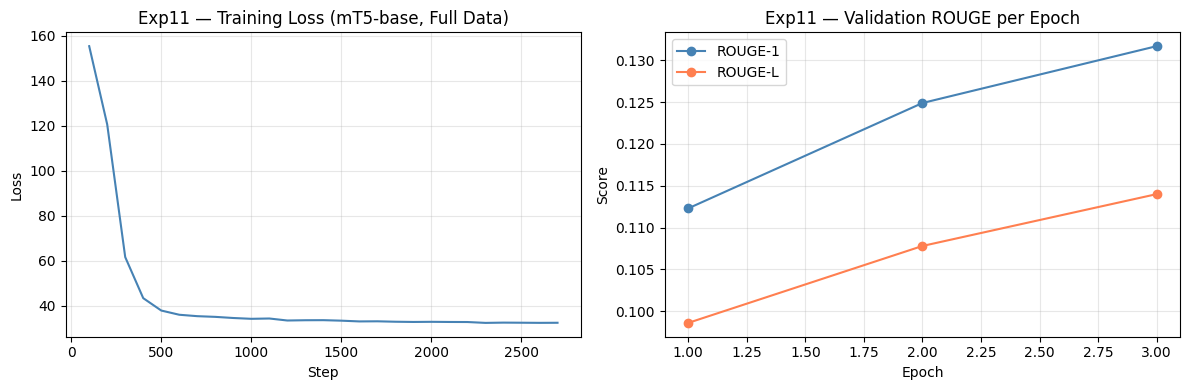

Plot saved


In [21]:
history    = pd.DataFrame(trainer.state.log_history)
train_logs = history.dropna(subset=["loss"])
eval_logs  = history.dropna(subset=["eval_ROUGE1"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_logs["step"], train_logs["loss"], color="steelblue")
axes[0].set_title("Exp11 — Training Loss (mT5-base, Full Data)")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGE1"],
             marker="o", label="ROUGE-1", color="steelblue")
axes[1].plot(eval_logs["epoch"], eval_logs["eval_ROUGEL"],
             marker="o", label="ROUGE-L", color="coral")
axes[1].set_title("Exp11 — Validation ROUGE per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/exp11_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot saved")